In [ ]:
import random
import sys
from pathlib import Path

BASE_DIR = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path.cwd().parent

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))


from eval.evaluator import RAGEvaluator
from src.rag.vector_db.vectorstore import QdrantClientWrapper

from src.utils import filter_non_header_documents, load_data

# Model ID
QWEN3 = "qwen3-0.6b"
SPLADE_V2 = "splade-pp-v2"
BGE_V2_M3 = "bge-v2-m3"
COHERE_RANKER_MODEL = "rerank-english-v3.0"

# Instruction
INSTRUCTION_DOC = (
    "This is a passage from the annual financial report of an Indonesian public company"
)
INSTRUCTION_QUERY = "Given a financial analysis or QA query, retrieve relevant passages from annual reports of Indonesian public companies"

# Collection
COLLECTION_NAME = "document"

QA_PAIRS_PATH = "../data/qa_evaluation_dataset_with_answers.json"
DOCUMENT_PATH = "../data/COMBINED_DATA.json"

Matplotlib is building the font cache; this may take a moment.


## Load Data

In [3]:
DATA = load_data(DOCUMENT_PATH)

random.shuffle(DATA)


CLEAN_DATA = filter_non_header_documents(DATA)
print(f"Total before filter: {len(DATA)}")
print(f"Total documents: {len(CLEAN_DATA)}")

Total before filter: 312
Total documents: 272


In [4]:
QA_EVAL_DATASET = load_data(QA_PAIRS_PATH)

for question in QA_EVAL_DATASET:
    print(f"ID: {question['id']}")
    print(f"Question: {question['question']}")
    print(f"Answer: {question['answer']}")
    print("=====" * 10)

ID: 222
Question: Can you describe the stock split performed by PT Bank Rakyat Indonesia (Persero) Tbk in 2017, including the nominal value change and key dates?
Answer: Based on Notarial Deed No. 54 dated October 27, 2017, PT Bank Rakyat Indonesia (Persero) Tbk performed a stock split in 2017, changing the nominal value per share from Rp250 to Rp50. The last day for trading shares with the old nominal value was November 9, 2017, and the new nominal value shares began trading on November 10, 2017.
ID: 256
Question: Who was the President Commissioner of PT BANK JAGO Tbk as of 31 December 2024?
Answer: Jerry Ng
ID: 266
Question: How does PT BANK JAGO Tbk classify its financial liabilities at initial recognition, and what are the characteristics and accounting treatment of financial liabilities classified as 'held for trading'?
Answer: At initial recognition, PT BANK JAGO Tbk classifies its financial liabilities based on their nature and purpose into measurement categories, one of which i

### Create Collection

In [5]:
qdrant_vectore_store = QdrantClientWrapper(is_local=False)

await qdrant_vectore_store.create_collection(COLLECTION_NAME, 1024)

2025-11-16 10:15:23.897 | SUCCESS  | src.rag.vector_db.vectorstore:__init__:64 - Successfully created remote Qdrant client
2025-11-16 10:15:25.068 | INFO     | src.rag.vector_db.vectorstore:create_collection:119 - Collection `documents` already exists.


### Upload Docs

In [17]:
await qdrant_vectore_store.upload_documents(
    collection_name=COLLECTION_NAME,
    sparse_model=SPLADE_V2,
    dense_model=QWEN3,
    documents=CLEAN_DATA,
    dense_instruction=INSTRUCTION_DOC,
    batch_size=32,
)

2025-11-16 10:04:07.141 | INFO     | src.rag.vector_db.vectorstore:upload_documents:159 - Uploading 272 documents to 'document'
2025-11-16 10:04:07.144 | INFO     | src.rag.vector_db.vectorstore:upload_documents:160 -   Dense model: qwen3-0.6b
2025-11-16 10:04:07.146 | INFO     | src.rag.vector_db.vectorstore:upload_documents:161 -   Sparse model: splade-pp-v2
2025-11-16 10:04:07.150 | INFO     | src.rag.vector_db.vectorstore:upload_documents:162 -   Batch size: 32
2025-11-16 10:04:07.152 | INFO     | src.rag.vector_db.vectorstore:upload_documents:165 - Disabling HNSW indexing for bulk upload...
Uploading batches: 100%|██████████| 9/9 [06:22<00:00, 42.48s/it]
2025-11-16 10:10:30.591 | SUCCESS  | src.rag.vector_db.vectorstore:upload_documents:240 - Upload complete: 272 succeeded, 0 failed
2025-11-16 10:10:30.592 | INFO     | src.rag.vector_db.vectorstore:upload_documents:244 - Re-enabling HNSW indexing...
2025-11-16 10:10:30.980 | INFO     | src.rag.vector_db.vectorstore:upload_document

{'successful': 272, 'failed': 0}

In [9]:
res = await qdrant_vectore_store.search(
    query=QA_EVAL_DATASET[5]["question"],
    collection_name=COLLECTION_NAME,
    sparse_model=SPLADE_V2,
    dense_model=QWEN3,
    dense_instruction=INSTRUCTION_QUERY,
    top_k=10,
    use_reranking=True,
    rerank_model=BGE_V2_M3,
    use_cohere=False,
    rerank_top_k=5,
)

for data in res:
    print(f"ID: {data['id']}")
    print(f"Score: {data['score']}")
    print(f"Score Rerank {data['rerank_score']}")
    print("\n")

2025-11-16 10:17:18.618 | INFO     | src.rag.vector_db.vectorstore:search:301 - Generating query embeddings...
2025-11-16 10:17:21.605 | INFO     | src.rag.vector_db.vectorstore:search:319 - Duration generate embedding & sparse: 2978.7ms
2025-11-16 10:17:21.615 | INFO     | src.rag.vector_db.vectorstore:search:321 - Start execute hybrid search...
2025-11-16 10:17:23.226 | INFO     | src.rag.vector_db.vectorstore:search:373 - 🔍 Retrieved 10 results in 1602.5ms
2025-11-16 10:17:23.230 | INFO     | src.rag.vector_db.vectorstore:search:401 - 🔄 Reranking with bge-v2-m3...
2025-11-16 10:17:36.500 | INFO     | src.rag.vector_db.vectorstore:search:422 - 🎯 Reranking completed in 13.27s
2025-11-16 10:17:36.504 | SUCCESS  | src.rag.vector_db.vectorstore:search:425 - ✅ Total time: 17.89s


ID: 110
Score: 0.33333334
Score Rerank 1.0


ID: 107
Score: 0.5
Score Rerank 0.9217546582221985


ID: 120
Score: 0.25
Score Rerank 0.8571326732635498


ID: 132
Score: 0.16666667
Score Rerank 0.03193560615181923


ID: 309
Score: 0.16666667
Score Rerank 0.0




## Evaluation Retrieval

In [12]:
evaluator = RAGEvaluator()

### Hybrid + Rerank
- Qwen-0.6B + Instruction
- prithivida/Splade_PP_en_v2
- BGE-M2-V3 Reranker

In [ ]:
df_results = await evaluator.evaluate_dataset(
    eval_dataset=QA_EVAL_DATASET,
    vector_store=qdrant_vectore_store,
    collection_name=COLLECTION_NAME,
    dense_model=QWEN3,
    sparse_model=SPLADE_V2,
    dense_instruction=INSTRUCTION_QUERY,
    top_k=20,
    use_reranking=True,
    rerank_model=BGE_V2_M3,
    use_cohere=False,
    rerank_top_k=10,
    verbose=True,
)

# evaluate top-k
metrics = evaluator.calculate_aggregate_metrics(k_values=[3, 5, 10, 20])

2025-11-16 10:53:14.146 | INFO     | eval.evaluator:plot_results:557 - 📊 Plot saved to: ../static/hybrid_reranking.png


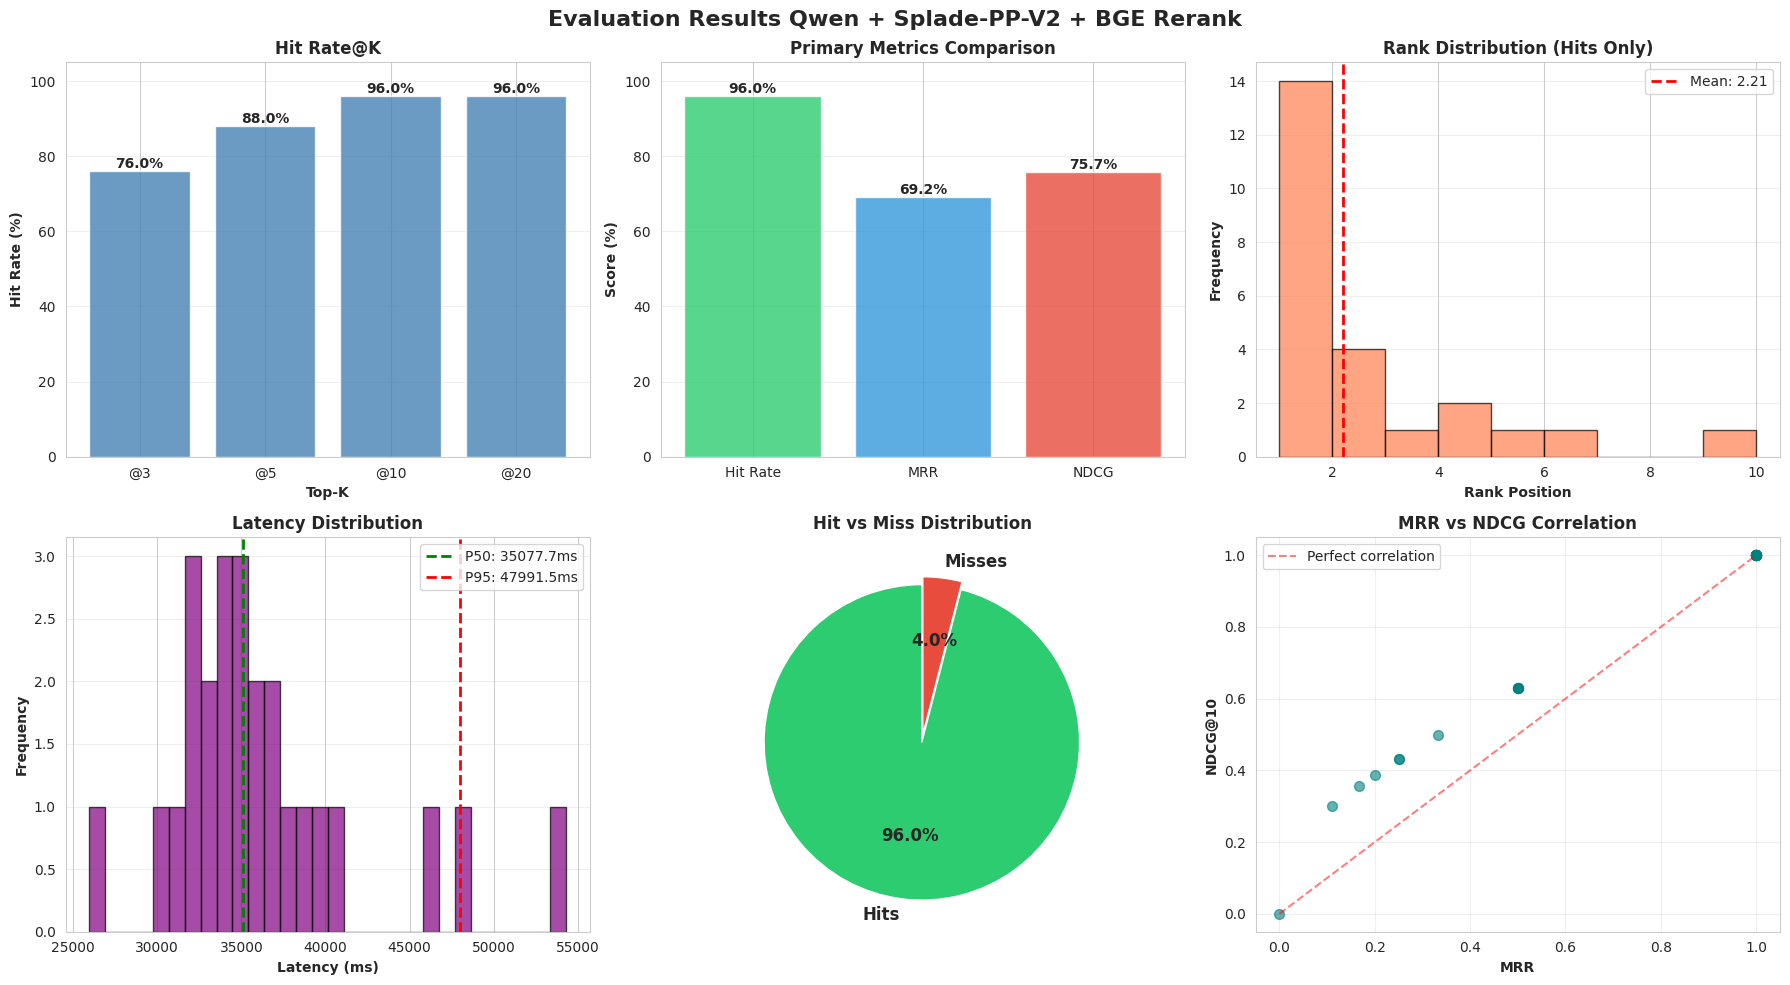

In [15]:
evaluator.plot_results(
    name="Qwen + Splade-PP-V2 + BGE Rerank",
    aggregate_metrics=metrics,
    df=df_results,
    save_path="../static/hybrid_reranking.png",
)

### Hybrid + Rerank
- Qwen-0.6B + Instruction
- prithivida/Splade_PP_en_v2
- Cohere Reranker

In [ ]:
df_results_2 = await evaluator.evaluate_dataset(
    eval_dataset=QA_EVAL_DATASET,
    vector_store=qdrant_vectore_store,
    collection_name=COLLECTION_NAME,
    dense_model=QWEN3,
    sparse_model=SPLADE_V2,
    dense_instruction=INSTRUCTION_QUERY,
    top_k=20,
    use_reranking=True,
    rerank_model=COHERE_RANKER_MODEL,
    use_cohere=True,
    rerank_top_k=10,
    verbose=True,
)

# evaluate top-k
metrics = evaluator.calculate_aggregate_metrics(k_values=[3, 5, 10, 20])

2025-11-16 10:58:59.927 | INFO     | eval.evaluator:plot_results:557 - 📊 Plot saved to: ../static/hybrid_reranking_cohere.png


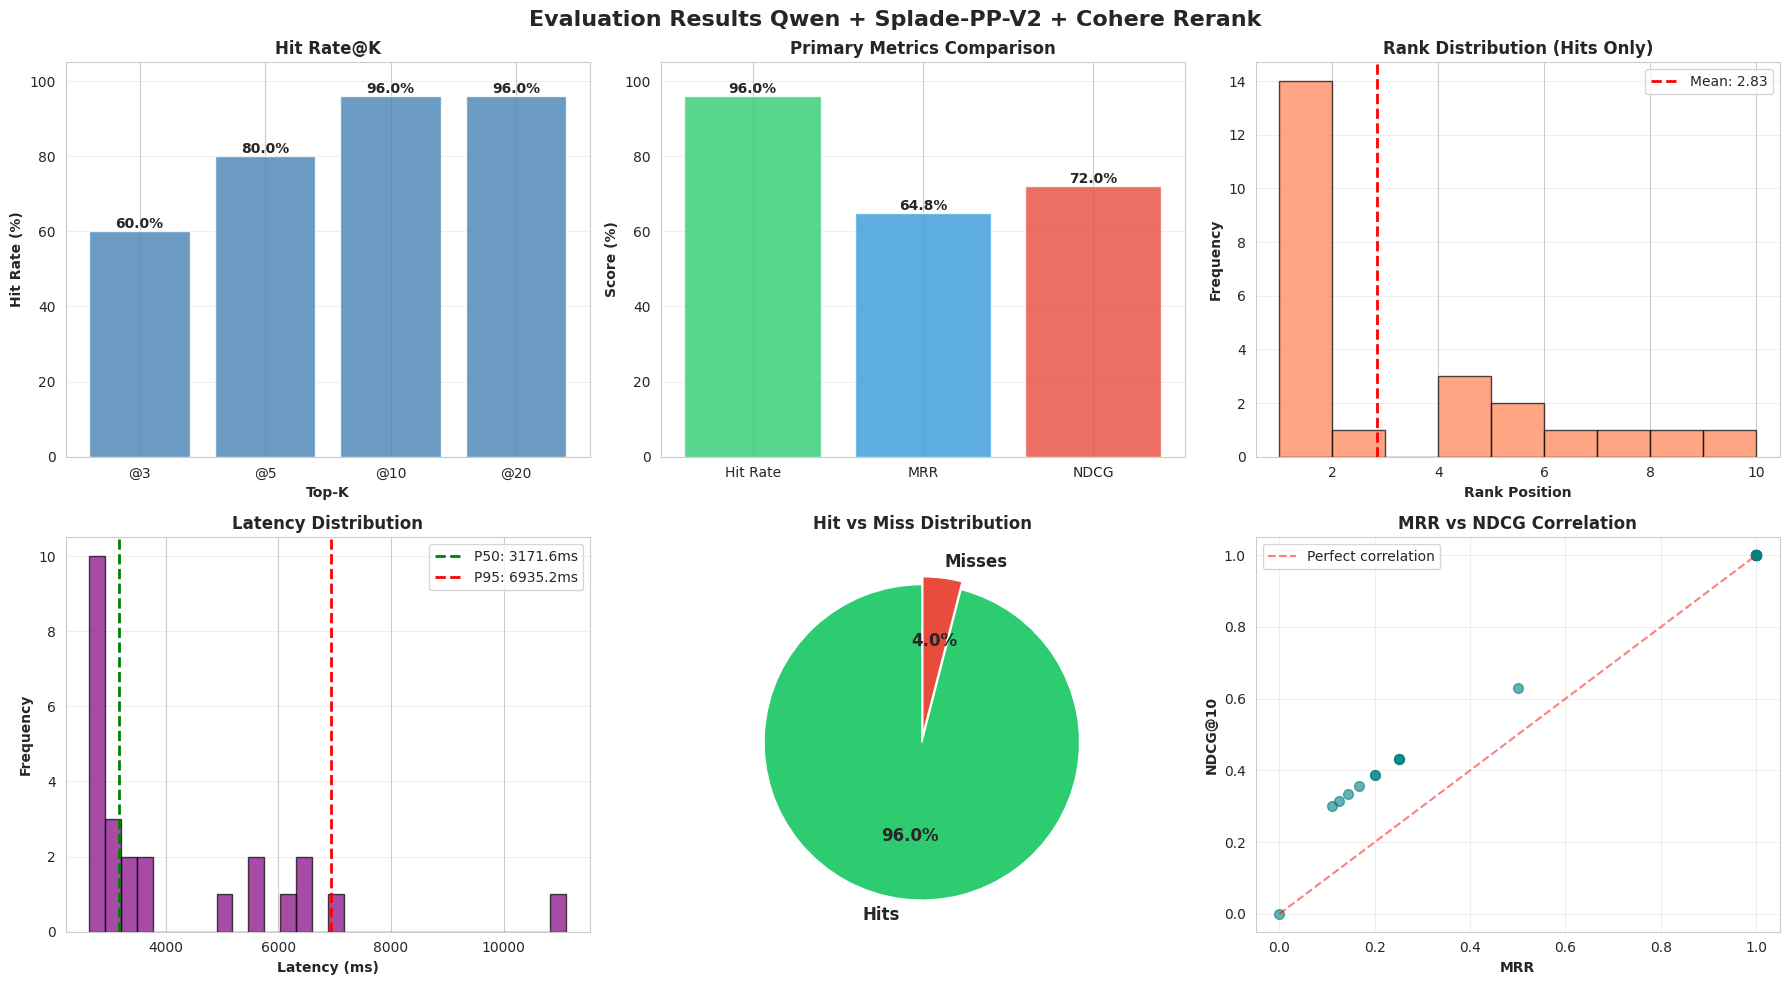

In [17]:
evaluator.plot_results(
    name="Qwen + Splade-PP-V2 + Cohere Rerank",
    aggregate_metrics=metrics,
    df=df_results_2,
    save_path="../static/hybrid_reranking_cohere.png",
)